In [1]:
# IMPORT LIBRARIES
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import re
from collections import Counter
!pip install Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import os


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
data = pd.read_csv(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\dataset_stance.csv")

In [4]:
data.head()

,no,_id,topic,title,content,stance,source,nnps
0,1,ObjectId(57139b4de79188d9599ce6c9),ahok,"Sungguh, Saya Benci Ahok Karena Prestasinya","[""Pesaing Ahok dalam Pilkada Jakarta 2017 nant...",for,http://www.kompasiana.com/yudipdanish/sungguh-...,"[""huhh"",""ahok"",""pilkada jakarta"",""ya"",""ahok ci..."
1,2,ObjectId(57139b4de79188d9599ce6ca),ahok,Ahok Tersandera KPK (2),"[""Hasil survey terbaru kepuasan publik terhada...",for,http://www.kompasiana.com/usmansantosa/ahok-te...,"[""parpol"",""kalijodo"",""haji lulung"",""ahok""]"
2,3,ObjectId(57139b4de79188d9599ce6cb),ahok,Ahok Butuh Dukungan Parpol,"[""Rasanya tidak etis menyianyiakan kesungguhan...",for,http://www.kompasiana.com/usmansantosa/ahok-bu...,"[""independen"",""setifaknya ahok"",""ahok"",""jakàrt..."
3,4,ObjectId(57139b4de79188d9599ce6cc),ahok,Pasangan yang Tepat untuk Ahok di Pilkada DKI,"[""pertama tama tentu saja saya mau mengucapkan...",for,http://www.kompasiana.com/agusganteng/pasangan...,[]
4,5,ObjectId(57139b4de79188d9599ce6cd),ahok,Bisakah Ahok Menjaga Momentum?,"[""Kepada media, Ahok mengatakan hubungan denga...",unknown,http://www.kompasiana.com/lora-dyah/bisakah-ah...,"[""warningyang"",""dki jakarta"",""provinsi dki jak..."


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 402 entries, 0 to 401
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   no       402 non-null    int64 
 1   _id      402 non-null    object
 2   topic    402 non-null    object
 3   title    402 non-null    object
 4   content  402 non-null    object
 5   stance   402 non-null    object
 6   source   402 non-null    object
 7   nnps     402 non-null    object
dtypes: int64(1), object(7)
memory usage: 25.2+ KB


##Data Cleaning

In [6]:
data.duplicated().sum()

0

In [7]:
data.isnull().sum()

no         0
_id        0
topic      0
title      0
content    0
stance     0
source     0
nnps       0
dtype: int64

In [8]:
data= data.drop(columns=["no", "_id", "topic", "nnps"])

In [9]:
data.head()

,title,content,stance,source
0,"Sungguh, Saya Benci Ahok Karena Prestasinya","[""Pesaing Ahok dalam Pilkada Jakarta 2017 nant...",for,http://www.kompasiana.com/yudipdanish/sungguh-...
1,Ahok Tersandera KPK (2),"[""Hasil survey terbaru kepuasan publik terhada...",for,http://www.kompasiana.com/usmansantosa/ahok-te...
2,Ahok Butuh Dukungan Parpol,"[""Rasanya tidak etis menyianyiakan kesungguhan...",for,http://www.kompasiana.com/usmansantosa/ahok-bu...
3,Pasangan yang Tepat untuk Ahok di Pilkada DKI,"[""pertama tama tentu saja saya mau mengucapkan...",for,http://www.kompasiana.com/agusganteng/pasangan...
4,Bisakah Ahok Menjaga Momentum?,"[""Kepada media, Ahok mengatakan hubungan denga...",unknown,http://www.kompasiana.com/lora-dyah/bisakah-ah...


#Data Pre Processing

In [10]:
# Mengubah string list menjadi plain text
def clean_content(x):
    try:
        return " ".join(ast.literal_eval(x))
    except:
        return x

data["content"] = data["content"].apply(clean_content)

In [11]:
# Gabungkan title + content
data["text"] = data["title"] + " " + data["content"]

In [12]:
data.head()

,title,content,stance,source,text
0,"Sungguh, Saya Benci Ahok Karena Prestasinya",Pesaing Ahok dalam Pilkada Jakarta 2017 nanti ...,for,http://www.kompasiana.com/yudipdanish/sungguh-...,"Sungguh, Saya Benci Ahok Karena Prestasinya Pe..."
1,Ahok Tersandera KPK (2),Hasil survey terbaru kepuasan publik terhadap ...,for,http://www.kompasiana.com/usmansantosa/ahok-te...,Ahok Tersandera KPK (2) Hasil survey terbaru k...
2,Ahok Butuh Dukungan Parpol,Rasanya tidak etis menyianyiakan kesungguhan t...,for,http://www.kompasiana.com/usmansantosa/ahok-bu...,Ahok Butuh Dukungan Parpol Rasanya tidak etis ...
3,Pasangan yang Tepat untuk Ahok di Pilkada DKI,pertama tama tentu saja saya mau mengucapkan s...,for,http://www.kompasiana.com/agusganteng/pasangan...,Pasangan yang Tepat untuk Ahok di Pilkada DKI ...
4,Bisakah Ahok Menjaga Momentum?,"Kepada media, Ahok mengatakan hubungan dengan ...",unknown,http://www.kompasiana.com/lora-dyah/bisakah-ah...,"Bisakah Ahok Menjaga Momentum? Kepada media, A..."


In [13]:
data['stance'].value_counts()

stance
for        177
against    123
unknown    102
Name: count, dtype: int64

In [14]:
# Hapus label tidak valid
data = data[data["stance"] != "unknown"]

In [15]:
# Mapping label ke Bahasa Indonesia
data["stance"] = data["stance"].replace({
    "for": "Mendukung",
    "against": "Membantah"
})

In [16]:
data["stance"].value_counts()

stance
Mendukung    177
Membantah    123
Name: count, dtype: int64

In [17]:
# Menghapus noise seperti URL, mention, simbol, dll
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URL
    text = re.sub(r"@\w+", "", text)            # remove mention
    text = re.sub(r"#", "", text)               # remove hashtag symbol
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # remove angka & simbol
    text = re.sub(r"\s+", " ", text).strip()    # normalize whitespace
    return text

data["clean_text"] = data["text"].apply(clean_text)

In [18]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp", "ga", "gak", "udah"]
all_words = " ".join(data['clean_text']).split()
word_counts = Counter(all_words)

for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Kata 'yg': muncul 53 kali
Kata 'tdk': muncul 3 kali
Kata 'dgn': muncul 3 kali
Kata 'hoax': muncul 4 kali
Kata 'bkn': muncul 0 kali
Kata 'klo': muncul 1 kali
Kata 'tp': muncul 1 kali
Kata 'ga': muncul 8 kali
Kata 'gak': muncul 52 kali
Kata 'udah': muncul 20 kali


In [19]:
slang_dict = {
    "yg": "yang",
    "tdk": "tidak",
    "dgn": "dengan",
    "hoax": "hoaks",
    "bkn": "bukan",
    "tp": "tapi",
    "klo": "kalau",
    "ga": "tidak",
    "gak": "tidak",
    "udah": "sudah"
}
def formalize(text):
    words = str(text).split()
    return " ".join([slang_dict.get(w, w) for w in words])

data['clean_text'] = data['clean_text'].apply(formalize)

In [20]:
target_slangs = ["yg", "tdk", "dgn", "hoax", "bkn", "klo", "tp", "ga", "gak", "udah"]
all_words = " ".join(data['clean_text']).split()
word_counts = Counter(all_words)

print("Pengecekan Slang di Dataset (Setelah Formalisasi):")
for slang in target_slangs:
    print(f"Kata '{slang}': muncul {word_counts[slang]} kali")

Pengecekan Slang di Dataset (Setelah Formalisasi):
Kata 'yg': muncul 0 kali
Kata 'tdk': muncul 0 kali
Kata 'dgn': muncul 0 kali
Kata 'hoax': muncul 0 kali
Kata 'bkn': muncul 0 kali
Kata 'klo': muncul 0 kali
Kata 'tp': muncul 0 kali
Kata 'ga': muncul 0 kali
Kata 'gak': muncul 0 kali
Kata 'udah': muncul 0 kali


In [22]:
# Definisi Stopwords dan Proteksi Kata Penting
factory = StopWordRemoverFactory()
base_stopwords = set(factory.get_stop_words())
custom_stopwords = set(open(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\stopwords_id.txt").read().split())
stopwords = base_stopwords.union(custom_stopwords)

positive_words = set(open(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\positif-indonesia.txt").read().split())
negative_words = set(open(r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\raw\negatif-indonesia.txt").read().split())

important_words = {"tidak", "bukan", "tanpa", "belum", "kurang"}
important_words = important_words.union(positive_words).union(negative_words)

stopwords = stopwords - important_words
def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in stopwords])

data["clean_text"] = data["clean_text"].apply(remove_stopwords)

In [23]:
data["clean_text"].head()

0    sungguh benci ahok prestasinya pesaing ahok pi...
1    ahok tersandera kpk hasil survey terbaru kepua...
2    ahok butuh dukungan parpol rasanya tidak etis ...
3    pasangan tepat ahok pilkada dki pertama tama m...
5    muslim dukung ahok salah judul diatas pembaca ...
Name: clean_text, dtype: object

In [24]:
# Mengukur panjang teks (jumlah kata)
data["text_length"] = data["clean_text"].apply(lambda x: len(x.split()))
print("Statistik Deskriptif Panjang Teks:")
print(data["text_length"].describe())

Statistik Deskriptif Panjang Teks:
count     300.000000
mean      433.346667
std       292.083978
min        53.000000
25%       227.000000
50%       352.500000
75%       574.250000
max      2389.000000
Name: text_length, dtype: float64


In [25]:
# Mengubah kata ke bentuk dasar
stemmer = StemmerFactory().create_stemmer()
data["clean_text"] = data["clean_text"].apply(stemmer.stem)
display(data["clean_text"].head())

0    sungguh benci ahok prestasi saing ahok pilkada...
1    ahok sandera kpk hasil survey baru puas publik...
2    ahok butuh dukung parpol rasa tidak etis menyi...
3    pasang tepat ahok pilkada dki pertama tama uca...
5    muslim dukung ahok salah judul atas baca apa s...
Name: clean_text, dtype: object

#Feature Engineering

In [26]:
# Menghitung jumlah kata positif & negatif dalam setiap teks
def sentiment_feature(text):
    words = text.split()

    pos_count = sum(1 for w in words if w in positive_words)
    neg_count = sum(1 for w in words if w in negative_words)

    return pos_count, neg_count

data[["pos_count", "neg_count"]] = data["clean_text"].apply(
    lambda x: pd.Series(sentiment_feature(x))
)
data["sentiment_score"] = data["pos_count"] - data["neg_count"]
data[["clean_text", "pos_count", "neg_count", "sentiment_score"]].head()

,clean_text,pos_count,neg_count,sentiment_score
0,sungguh benci ahok prestasi saing ahok pilkada...,8,9,-1
1,ahok sandera kpk hasil survey baru puas publik...,12,9,3
2,ahok butuh dukung parpol rasa tidak etis menyi...,9,5,4
3,pasang tepat ahok pilkada dki pertama tama uca...,15,2,13
5,muslim dukung ahok salah judul atas baca apa s...,10,9,1


#EDA

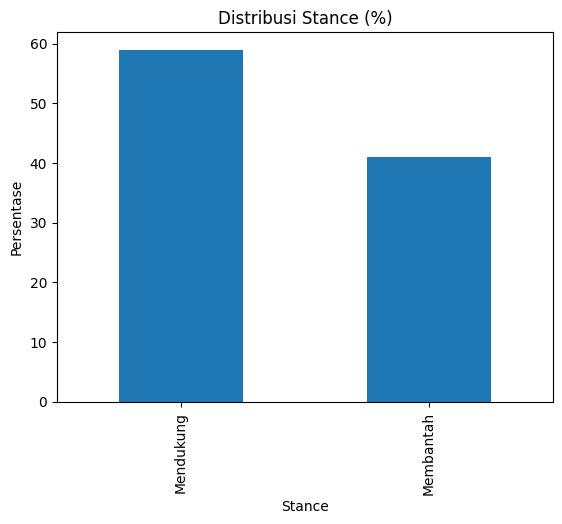

In [27]:
plt.figure()

(data["stance"].value_counts(normalize=True) * 100).plot(kind="bar")

plt.title("Distribusi Stance (%)")
plt.ylabel("Persentase")
plt.xlabel("Stance")

plt.show()

In [28]:
data[['clean_text']].head()
data.shape
data['stance'].value_counts(normalize=True)

stance
Mendukung    0.59
Membantah    0.41
Name: proportion, dtype: float64

Distribusi stance menunjukkan bahwa kelas “Mendukung” lebih dominan dengan sekitar 59% dibandingkan “Membantah” sekitar 41%. Hal ini mengindikasikan adanya sedikit ketidakseimbangan data, namun masih dalam batas wajar sehingga model masih dapat belajar dengan baik, meskipun tetap perlu diperhatikan agar tidak bias terhadap kelas mayoritas.

count     300.000000
mean      433.346667
std       292.083978
min        53.000000
25%       227.000000
50%       352.500000
75%       574.250000
max      2389.000000
Name: text_length, dtype: float64


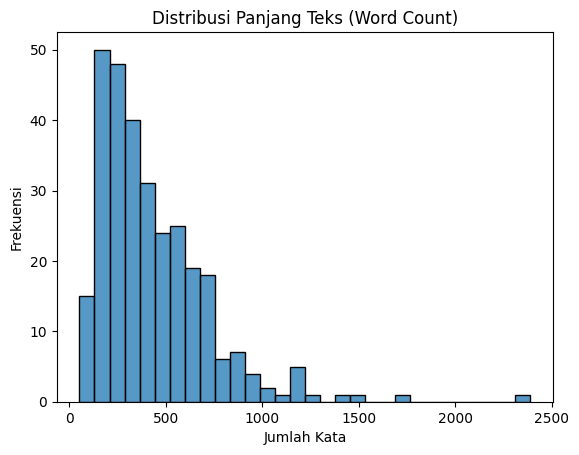

In [29]:
# Mengukur panjang teks (jumlah kata) dan Melihat distribusi panjang teks
data["text_length"] = data["clean_text"].apply(lambda x: len(x.split()))
print(data["text_length"].describe())
plt.figure()
sns.histplot(data["text_length"], bins=30)
plt.title("Distribusi Panjang Teks (Word Count)")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

Distribusi panjang teks menunjukkan bahwa sebagian besar data berada pada rentang menengah dengan rata-rata sekitar 433 kata dan median 352 kata, yang mengindikasikan distribusi cenderung right-skewed (miring ke kanan). Hal ini diperkuat dengan adanya perbedaan cukup besar antara nilai maksimum (2389 kata) dan kuartil atas (574 kata), yang menandakan keberadaan beberapa outlier teks sangat panjang. Sebagian besar data terkonsentrasi pada rentang 200–600 kata, sehingga dapat disimpulkan bahwa mayoritas dokumen memiliki panjang moderat, sementara sebagian kecil teks ekstrem berpotensi mempengaruhi analisis maupun performa model jika tidak ditangani dengan baik.

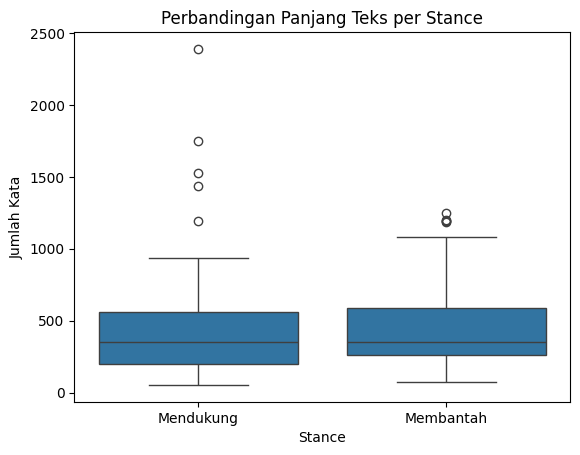

In [30]:
#Text Length per Stance
plt.figure()
sns.boxplot(x="stance", y="text_length", data=data)

plt.title("Perbandingan Panjang Teks per Stance")
plt.xlabel("Stance")
plt.ylabel("Jumlah Kata")

plt.show()

Perbandingan panjang teks berdasarkan stance menunjukkan bahwa kedua kelas, “Mendukung” dan “Membantah”, memiliki distribusi yang relatif mirip dengan median yang tidak jauh berbeda, meskipun “Membantah” cenderung memiliki panjang teks sedikit lebih tinggi dan variasi yang lebih lebar. Hal ini mengindikasikan bahwa teks yang bersifat membantah umumnya disertai argumen yang lebih panjang atau kompleks. Selain itu, terdapat beberapa outlier pada kedua kelas, terutama pada “Mendukung” yang memiliki nilai ekstrem hingga lebih dari 2000 kata. Secara keseluruhan, panjang teks bukan menjadi pembeda utama antar stance karena distribusinya cukup overlap.

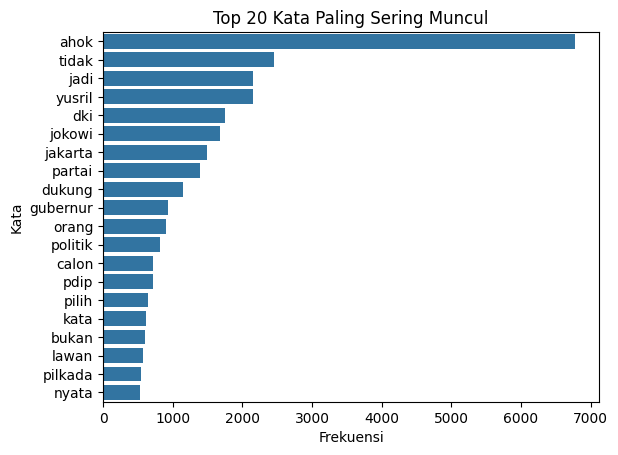

In [31]:
# Menemukan kata paling sering muncul
all_words = " ".join(data["clean_text"]).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(20)
df_top_words = pd.DataFrame(top_words, columns=["word", "count"])

# Visualisasi
plt.figure()
sns.barplot(x="count", y="word", data=df_top_words)
plt.title("Top 20 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

Distribusi kata menunjukkan bahwa topik utama dataset berfokus pada isu politik, terutama terkait figur seperti “ahok” serta konteks DKI Jakarta dan pilkada. Kemunculan kata seperti “tidak” dan “bukan” juga menandakan banyaknya opini atau pernyataan kontradiktif, yang relevan untuk analisis stance.


Top words untuk stance: Mendukung


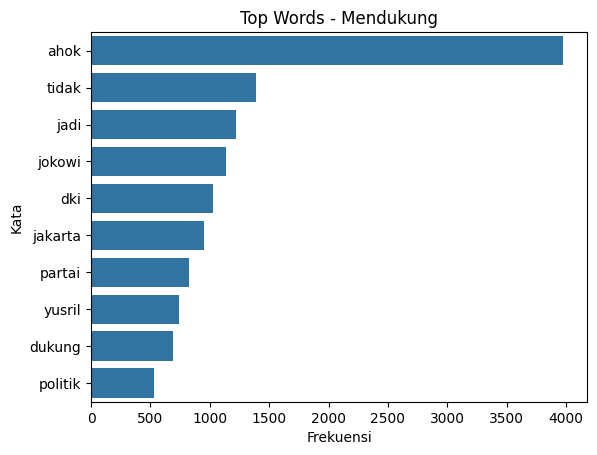


Top words untuk stance: Membantah


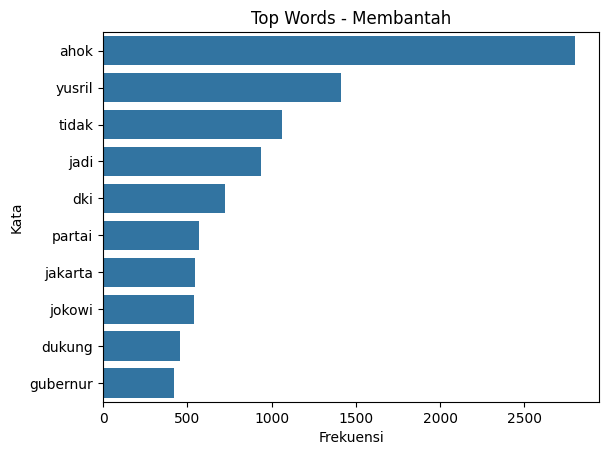

In [32]:
#Lihat kata dominan di tiap label
def get_top_words(text_series, n=10):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

for stance in data["stance"].unique():
    print(f"\nTop words untuk stance: {stance}")
    subset = data[data["stance"] == stance]["clean_text"]
    top_words = get_top_words(subset, 10)
    df = pd.DataFrame(top_words, columns=["word", "count"])

    plt.figure()
    sns.barplot(x="count", y="word", data=df)
    plt.title(f"Top Words - {stance}")
    plt.xlabel("Frekuensi")
    plt.ylabel("Kata")
    plt.show()

Distribusi kata pada kedua stance menunjukkan pola yang cukup mirip, dengan “ahok” sebagai kata paling dominan di kedua kelas. Namun, pada stance “Membantah”, kata seperti “yusril” muncul lebih menonjol, mengindikasikan fokus argumen atau perbandingan tokoh. Sementara itu, kata-kata umum seperti “tidak” dan “jadi” muncul di kedua sisi, menunjukkan adanya overlap konteks. Secara keseluruhan, perbedaan kata antar stance tidak terlalu kontras, sehingga klasifikasi lebih bergantung pada konteks kalimat daripada sekadar frekuensi kata.

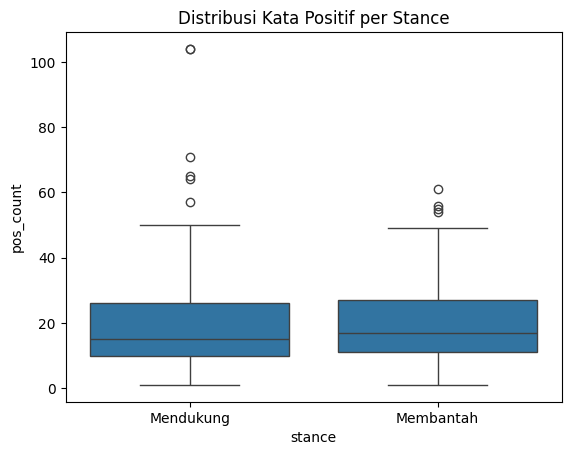

In [33]:
plt.figure()
sns.boxplot(x="stance", y="pos_count", data=data)
plt.title("Distribusi Kata Positif per Stance")
plt.show()

Distribusi menunjukkan bahwa kedua stance memiliki jumlah kata positif yang relatif mirip, meskipun “Membantah” sedikit lebih tinggi pada median dan variasinya. Hal ini mengindikasikan bahwa penggunaan kata positif tidak secara signifikan membedakan antara kedua kelas, sehingga bukan menjadi indikator utama dalam menentukan stance.

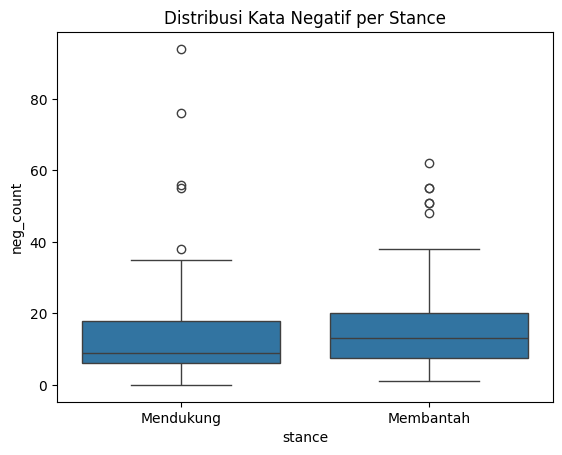

In [34]:
plt.figure()
sns.boxplot(x="stance", y="neg_count", data=data)
plt.title("Distribusi Kata Negatif per Stance")
plt.show()

Distribusi menunjukkan bahwa stance “Membantah” cenderung memiliki jumlah kata negatif yang lebih tinggi dibandingkan “Mendukung”, baik dari sisi median maupun variasinya. Hal ini mengindikasikan bahwa teks yang bersifat membantah lebih banyak mengandung ekspresi negatif atau kritik, sehingga kata negatif menjadi indikator yang cukup kuat dalam membedakan kedua stance.

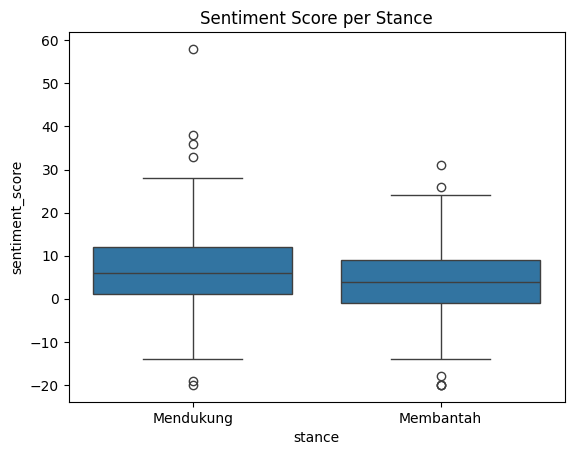

In [35]:
plt.figure()
sns.boxplot(x="stance", y="sentiment_score", data=data)
plt.title("Sentiment Score per Stance")
plt.show()

Distribusi sentiment score menunjukkan bahwa kedua stance memiliki nilai yang cukup overlap, namun “Mendukung” cenderung memiliki skor sedikit lebih tinggi (lebih positif) dibandingkan “Membantah”. Sementara itu, “Membantah” memiliki variasi yang lebih besar ke arah negatif, yang mengindikasikan adanya kecenderungan penggunaan kata bernuansa negatif. Hal ini menunjukkan bahwa sentiment score dapat menjadi indikator tambahan dalam membedakan stance, meskipun bukan satu-satunya faktor penentu.

#Encoding Label

In [36]:
le = LabelEncoder()
data["label"] = le.fit_transform(data["stance"])
data[["stance", "label"]].head()

,stance,label
0,Mendukung,1
1,Mendukung,1
2,Mendukung,1
3,Mendukung,1
5,Mendukung,1


#Data Dictionary
- title            : Judul berita
- content          : Isi berita
- text             : Gabungan title + content
- clean_text       : Teks setelah preprocessing
- stance           : Label kategori (Mendukung / Membantah)
- label            : Label numerik
- text_length      : Jumlah kata dalam teks
- pos_count        : Jumlah kata positif
- neg_count        : Jumlah kata negatif
- sentiment_score  : Selisih positif - negatif

#Data Final

In [37]:
# Menyimpan data yang sudah siap untuk modeling
final_data = data[[
    "clean_text",
    "label",
    "pos_count",
    "neg_count",
    "sentiment_score"
]]

# Cek hasil
final_data.head()
final_data.shape

# Simpan ke CSV
output_dir = r"C:\Users\hanao\Downloads\hoax-detector\ds-role\dataset\final"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "final_data_stance.csv")
final_data.to_csv(file_path, index=False)
print("Dataset berhasil disimpan sebagai 'final_data_stance.csv'")

Dataset berhasil disimpan sebagai 'final_data_stance.csv'


###Nama nama kolom di tabel final
- clean_text       : Teks setelah preprocessing
- label            : Label numerik
- pos_count        : Jumlah kata positif
- neg_count        : Jumlah kata negatif
- sentiment_score  : Selisih positif - negatif

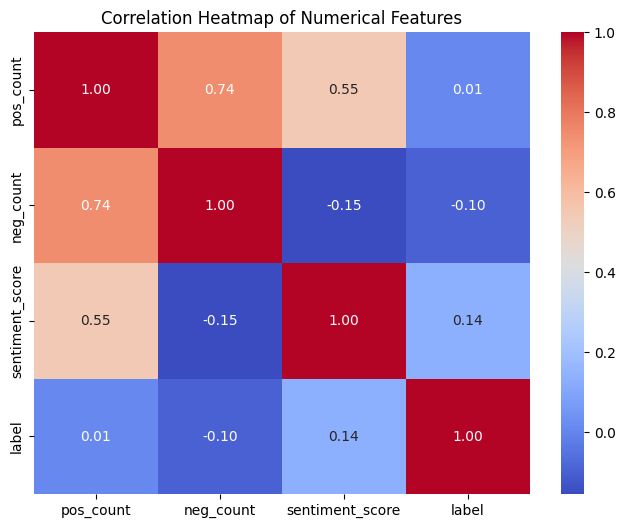

In [38]:
correlation_matrix = final_data[['pos_count', 'neg_count', 'sentiment_score','label']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()